Data Description / Processing Script
-----------------------------------------------------------
Input : sales_data.csv
Output: variable_dictionary.csv, data_profile.csv, sales_stats.csv, outliers_iqr.csv, segment_summary.csv

What it does:
1) Load CSV
2) Create a variable dictionary (types, unique counts, missingness)
3) Summarize dataset size/scope (rows, #stores, #models, date_min, date_max, days_span)
4) Compute sales distribution + IQR outlier thresholds; export flagged rows
5) Aggregate to monthly per store-model and compute:
   - zero_share (share of zero months)
   - ADI (average inter-demand interval, months)
   - ACF12 (autocorrelation at 12-month lag)
   - segment labels: intermittent / seasonal / regular

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Bad value in file WindowsPath('C:/Users/dell/.matplotlib/stylelib/my_style.mplstyle'), line 8 ('axes.facecolor: #FFFFFF'): Key axes.facecolor: '' does not look like a color arg


In [18]:
df = pd.read_csv('../data/raw/sales_data.csv') 

df.info() # check for missing values
df.isnull().sum() # count missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185292 entries, 0 to 185291
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   Date     185292 non-null  object
 1   StoreId  185292 non-null  object
 2   ItemId   185292 non-null  object
 3   Sales    185292 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 5.7+ MB


Date       0
StoreId    0
ItemId     0
Sales      0
dtype: int64

In [19]:
# Number of rows and columns
print("Shape:", df.shape)

# List of column names
print("Columns:", df.columns.tolist())

df.head()


Shape: (185292, 4)
Columns: ['Date', 'StoreId', 'ItemId', 'Sales']


,Date,StoreId,ItemId,Sales
0,2023-07-01,01eecfe8-8d58-4f28-b224-8d1684acf561,eb704803-8835-40a5-bd47-f5e4519d7f41,1
1,2023-07-01,04b246ce-8d4e-459a-8125-ac75f29d878f,06a74f8a-7164-4158-bafa-73bf266a249a,1
2,2023-07-01,04b246ce-8d4e-459a-8125-ac75f29d878f,eb704803-8835-40a5-bd47-f5e4519d7f41,1
3,2023-07-01,04c9c2f5-d95d-490c-8821-a6ecbb305ad1,4f90622a-a55c-4047-a68c-05ac205518d3,1
4,2023-07-01,0a1123d9-4a33-4cca-a3d7-3c7a014d88da,9378e5d0-1274-421d-a05e-938711b6f30b,1


In [20]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print("Min date:", df['Date'].min())
print("Max date:", df['Date'].max())


Min date: 2023-07-01 00:00:00
Max date: 2025-08-01 00:00:00


In [21]:
df['Sales'].describe()


count    185292.00000
mean          1.09702
std           0.53235
min           1.00000
25%           1.00000
50%           1.00000
75%           1.00000
max          38.00000
Name: Sales, dtype: float64

In [22]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print(f"Number of outliers: {outliers.shape[0]}")

Number of outliers: 13068


In [23]:
print("Unique stores:", df['StoreId'].nunique())
print("Unique models:", df['ItemId'].nunique())


Unique stores: 750
Unique models: 84


Date
2023-07-31    8631
2023-08-31    9214
2023-09-30    8090
2023-10-31    6573
2023-11-30    5313
Freq: ME, Name: Sales, dtype: int64


C:\Users\dell\AppData\Local\Temp\ipykernel_22376\251184811.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key='Date', freq='M'))['Sales'].sum()


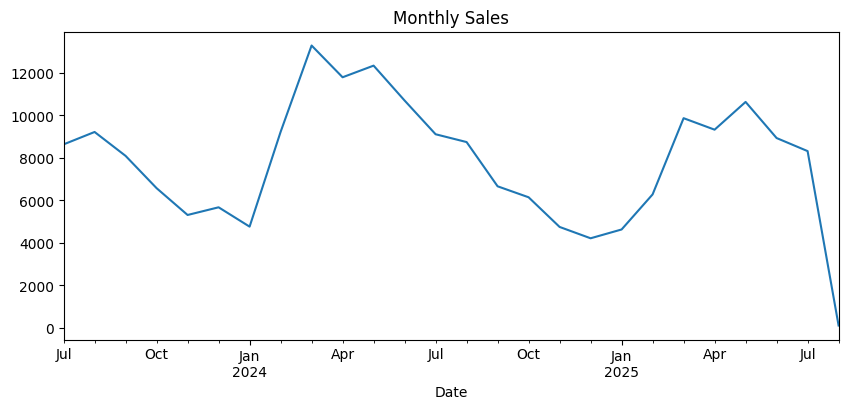

In [24]:
monthly_sales = df.groupby(pd.Grouper(key='Date', freq='M'))['Sales'].sum()
print(monthly_sales.head())

# monthly sales
monthly_sales.plot(figsize=(10,4), title='Monthly Sales')
plt.show()


In [25]:
# Parse Date to datetime
def parse_ymd_slashy(s):
    s = (s.astype(str)
           .str.strip()
           .str.replace('.', '/', regex=False)
           .str.replace('-', '/', regex=False))
    
    dt = pd.to_datetime(s, format='%Y/%m/%d', errors='coerce')
    needs_fallback = dt.isna().any()
    if needs_fallback:
        dt = pd.to_datetime(s, errors='coerce', dayfirst=False)
    return dt

df['Date'] = parse_ymd_slashy(df['Date'])
df = df.dropna(subset=['Date']).sort_values('Date')


In [26]:
#  drop an incomplete LAST month (Aug 1 present)
max_raw_date = df['Date'].max()
month_end = max_raw_date.to_period('M').asfreq('M').to_timestamp()  # end of that month
if max_raw_date < month_end:
    # remove that partial month from downstream aggregation
    cutoff = max_raw_date.to_period('M').start_time  # start of that month
    df_model = df[df['Date'] < cutoff].copy()
else:
    df_model = df.copy()

In [27]:
# Monthly aggregation per store–item
monthly = (
    df_model.set_index('Date')
            .groupby(['StoreId', 'ItemId'])['Sales']
            .resample('MS')                 # month-start buckets; ME for month-end
            .sum()
            .reset_index()
            .rename(columns={'Sales': 'units'})
)



In [ ]:
monthly.describe()


,Date,units
count,266650,266650.000000
mean,2024-06-21 22:49:05.290080768,0.762306
min,2023-07-01 00:00:00,0.000000
25%,2024-01-01 00:00:00,0.000000
50%,2024-06-01 00:00:00,0.000000
75%,2024-12-01 00:00:00,1.000000
max,2025-08-01 00:00:00,115.000000
std,NaN,1.418111


In [30]:
monthly.to_csv("../data/processed/monthly.csv", index=False)

In [12]:
# Mean monthly sales per series (for sparsity)
monthly_mean = (
    monthly.groupby(['StoreId', 'ItemId'])['units']
           .mean()
           .rename('mean_monthly_sales')
           .reset_index()
)



In [13]:
# sparse threshold
thr = monthly_mean['mean_monthly_sales'].quantile(0.25)  # lower quartile
monthly_mean['demand_class'] = np.where(
    monthly_mean['mean_monthly_sales'] <= thr, 'sparse', 'active'
)

print("Sparse threshold (25th pct):", round(thr, 3))
print("Share labeled sparse:", (monthly_mean['demand_class']=='sparse').mean().round(3))

Sparse threshold (25th pct): 0.4
Share labeled sparse: 0.269


In [ ]:
# Variable description table
variable_summary = pd.DataFrame({
    'Variable': df.columns,
    'Type': [df[col].dtype for col in df.columns],
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Missing Values': [df[col].isna().sum() for col in df.columns],
    'Missing (%)': [round(df[col].isna().mean() * 100, 2) for col in df.columns]
})
print("=== Variable Description ===")
print(variable_summary)

variable_summary.to_csv('../data/processed/variable_description.csv', index=False)

# Descriptive stats for Sales
sales_summary = df['Sales'].describe(percentiles=[0.25, 0.5, 0.75]).to_frame().T
print("\n=== Sales Descriptive Statistics ===")
print(sales_summary.round(2))

sales_summary.to_csv('../data/processed/sales_summary.csv', index=False)

# Sparse vs Active segments summary
sparse_threshold = monthly_mean['mean_monthly_sales'].quantile(0.25)
sparse_count = (monthly_mean['mean_monthly_sales'] <= sparse_threshold).sum()
active_count = (monthly_mean['mean_monthly_sales'] > sparse_threshold).sum()
total_series = len(monthly_mean)

sparse_table = pd.DataFrame({
    'Category': ['Sparse', 'Active'],
    'Threshold (mean units/month)': [f"≤ {sparse_threshold:.1f}", f"> {sparse_threshold:.1f}"],
    '# Series': [sparse_count, active_count],
    'Share (%)': [round(100 * sparse_count / total_series, 1),
                  round(100 * active_count / total_series, 1)]
})
print("\n=== Sparse vs Active Segments ===")
print(sparse_table)

sparse_table.to_csv('../data/processed/sparse_active_summary.csv', index=False)

#Temporal coverage summary
temporal_table = pd.DataFrame({
    'Start Date': [df['Date'].min().date()],
    'End Date': [df['Date'].max().date()],
    '# of Days': [(df['Date'].max() - df['Date'].min()).days + 1],
    '# of Months': [((df['Date'].max().year - df['Date'].min().year) * 12
                    + df['Date'].max().month - df['Date'].min().month + 1)],
    'Frequency': ['Daily'],
    'Notes': ['Last month may be partial' if df['Date'].max().day < 20 else '']
})
print("\n=== Temporal Coverage ===")
print(temporal_table)


=== Variable Description ===
  Variable            Type  Unique Values  Missing Values  Missing (%)
0     Date  datetime64[ns]            762               0          0.0
1  StoreId          object            750               0          0.0
2   ItemId          object             84               0          0.0
3    Sales           int64             31               0          0.0

=== Sales Descriptive Statistics ===
          count  mean   std  min  25%  50%  75%   max
Sales  185292.0   1.1  0.53  1.0  1.0  1.0  1.0  38.0

=== Sparse vs Active Segments ===
  Category Threshold (mean units/month)  # Series  Share (%)
0   Sparse                        ≤ 0.4      6588       26.9
1   Active                        > 0.4     17874       73.1

=== Temporal Coverage ===
   Start Date    End Date  # of Days  # of Months Frequency  \
0  2023-07-01  2025-08-01        763           26     Daily   

                       Notes  
0  Last month may be partial  


Seasonality and Demand Pattern

In [ ]:

from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import STL
import warnings
warnings.filterwarnings("ignore")

# Helper functions
def compute_adi(units: np.ndarray) -> float:
    """Average Inter-Demand Interval (in months)."""
    nz = np.where(units > 0)[0]
    if len(nz) < 2:
        return np.nan
    return float(np.diff(nz).mean())

def compute_acf12(units: np.ndarray) -> float:
    """Autocorrelation at 12-month lag."""
    if len(units) < 13:
        return np.nan
    try:
        return float(acf(units, nlags=12, fft=True)[12])
    except Exception:
        return np.nan

def compute_seasonal_strength(units: np.ndarray, period: int = 12) -> float:
    """STL-based seasonal strength."""
    if len(units) < 2 * period:
        return np.nan
    try:
        stl = STL(units, period=period, robust=True).fit()
        seasonal, resid = stl.seasonal, stl.resid
        var_r = np.var(resid)
        var_rs = np.var(resid + seasonal)
        return float(max(0, min(1, 1 - var_r / var_rs))) if var_rs > 0 else 0.0
    except Exception:
        return np.nan

In [ ]:
# Compute metrics per StoreId–ItemId
records = []
for (store, item), grp in monthly.groupby(["StoreId", "ItemId"]):
    y = grp["units"].to_numpy()
    if len(y) < 6:  # skip extremely short series
        continue
    rec = {
        "StoreId": store,
        "ItemId": item,
        "n_months": len(y),
        "zero_share": (y == 0).mean(),
        "mean_units": y.mean(),
        "std_units": y.std(ddof=1),
        "ADI": compute_adi(y),
        "ACF12": compute_acf12(y),
        "seasonal_strength": compute_seasonal_strength(y),
    }
    rec["cv_units"] = rec["std_units"] / rec["mean_units"] if rec["mean_units"] > 0 else np.nan
    records.append(rec)

series_metrics = pd.DataFrame(records)
print(f"Computed metrics for {len(series_metrics)} store–item series")

# Label demand pattern
def classify_pattern(row):
    zs, adi, acf12, ss = row["zero_share"], row["ADI"], row["ACF12"], row["seasonal_strength"]
    if (zs >= 0.5) and (adi >= 1.5 if not np.isnan(adi) else False):
        return "intermittent"
    if ((acf12 >= 0.5 if not np.isnan(acf12) else False) or
        (ss >= 0.5 if not np.isnan(ss) else False)):
        return "seasonal"
    return "regular"

series_metrics["pattern_label"] = series_metrics.apply(classify_pattern, axis=1)

# Merge with sparse/active classification
series_full = series_metrics.merge(
    monthly_mean[["StoreId", "ItemId", "demand_class"]],
    on=["StoreId", "ItemId"],
    how="left"
)

# Summary tables
pattern_summary = (series_full["pattern_label"]
                   .value_counts()
                   .rename_axis("pattern_label")
                   .reset_index(name="n_series"))
pattern_summary["share_%"] = (100 * pattern_summary["n_series"] /
                              pattern_summary["n_series"].sum()).round(1)

print("\n=== Pattern Distribution ===")
print(pattern_summary)

ct = pd.crosstab(series_full["demand_class"], series_full["pattern_label"])
print("\n=== Demand Class vs Pattern Label ===")
print(ct)

series_full.to_csv("../data/processed/series_pattern_summary.csv", index=False)
pattern_summary.to_csv("../data/processed/pattern_summary_table.csv", index=False)

In [ ]:
np.random.seed(42)
sample_ids = (series_full.groupby("pattern_label")
               .apply(lambda g: g.sample(3)[["StoreId","ItemId","pattern_label"]])
               .reset_index(drop=True))
print(sample_ids)

monthly.to_csv("../data/processed/monthly_processed.csv", index=False)
sample_ids.to_csv("../data/processed/sample_ids.csv", index=False)

monthly_with_pattern = monthly.merge(
    series_metrics[["StoreId", "ItemId", "pattern_label"]],
    on=["StoreId", "ItemId"],
    how="left"
)
monthly_with_pattern.to_csv("../data/processed/monthly_with_pattern.csv", index=False)



                                StoreId                                ItemId  \
0  571062ad-0b1d-42d4-9381-b751237f7558  89dfbc8d-f16a-4176-ad0a-e490baacbcdd   
1  d9f7878a-927e-4d1f-96b4-20b5081eaa8e  dea1d2ab-2164-4247-b50b-14a87473a366   
2  07614761-58a0-4db1-be64-f4630091d9b8  eb704803-8835-40a5-bd47-f5e4519d7f41   
3  6ced3ba7-1352-40be-94fc-0b11d3182d8d  3289436a-4880-45c5-9c21-41894163f610   
4  5de6ad56-3364-48a4-aa65-3c3fec73f36f  eabaaf99-d080-4833-9910-9371f90e0cc7   
5  07614761-58a0-4db1-be64-f4630091d9b8  b2106625-1dce-46e8-9ee2-f42ba23c9970   
6  9141075c-9c64-4421-a7b2-2a56e3500130  8a7fa800-6ae2-4b64-ada5-f7bbf0bb7fcd   
7  bf923369-5d9d-443a-a368-f225eff052d2  f9c7a0d1-c07f-4d69-b189-8f15672c9cbd   
8  02a6faa8-5940-450f-9da1-29a78f806f05  eabaaf99-d080-4833-9910-9371f90e0cc7   

  pattern_label  
0  intermittent  
1  intermittent  
2  intermittent  
3       regular  
4       regular  
5       regular  
6      seasonal  
7      seasonal  
8      seasonal  


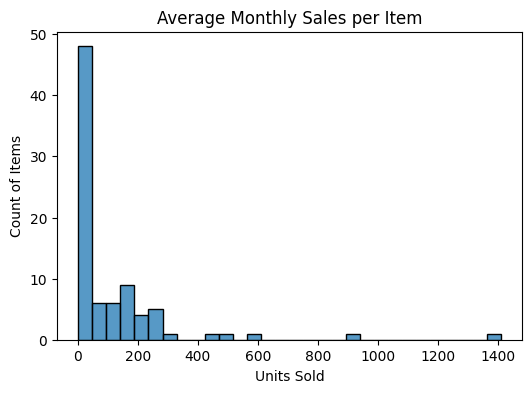

In [10]:
df_m = df.groupby(['ItemId', df['Date'].dt.to_period('M')])['Sales'].sum().reset_index()
df_m['Date'] = df_m['Date'].astype(str)

item_monthly_avg = df_m.groupby('ItemId')['Sales'].mean()

plt.figure(figsize=(6,4))
sns.histplot(item_monthly_avg, bins=30)
plt.title("Average Monthly Sales per Item")
plt.xlabel("Units Sold")
plt.ylabel("Count of Items")
plt.show()



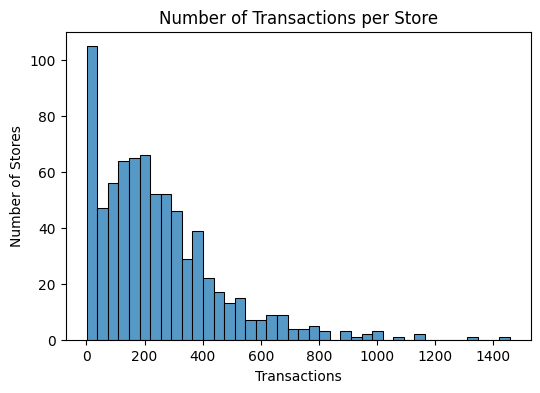

In [ ]:
tx_per_store = df.groupby('StoreId').size()

plt.figure(figsize=(6,4))
sns.histplot(tx_per_store, bins=40)
plt.title("Number of Transactions per Store")
plt.xlabel("Transactions")
plt.ylabel("Number of Stores")

#plt.savefig(f'../docs/p1/transactions_per_store.png', dpi=300, bbox_inches='tight')
plt.show()


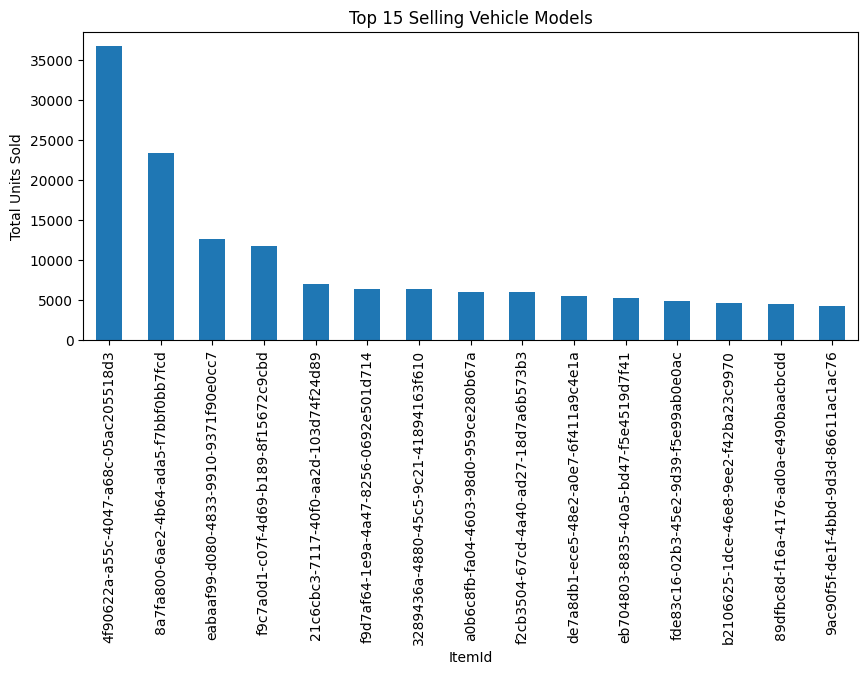

In [14]:
item_total_sales = df.groupby('ItemId')['Sales'].sum().sort_values(ascending=False)

item_total_sales.head(15).plot(kind='bar', figsize=(10,4))
plt.title("Top 15 Selling Vehicle Models")
plt.xlabel("ItemId")
plt.ylabel("Total Units Sold")
plt.savefig(f'../docs/p1/top15_item.png', dpi=300, bbox_inches='tight')
plt.show()

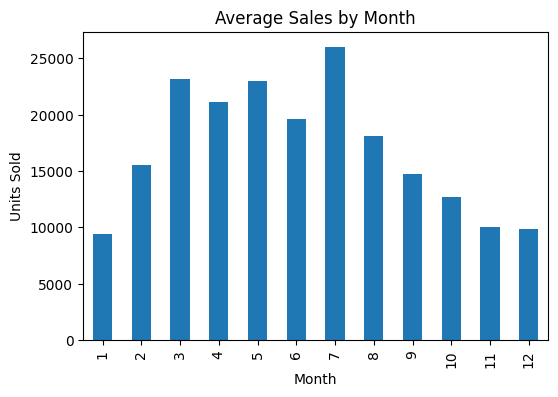

In [16]:
#aggregates ALL years together by month
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(6,4))
monthly_avg.plot(kind='bar')
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Units Sold")


plt.savefig(f"../docs/p1/12_m_seasonality plot.png", dpi=300, bbox_inches='tight')
plt.show()


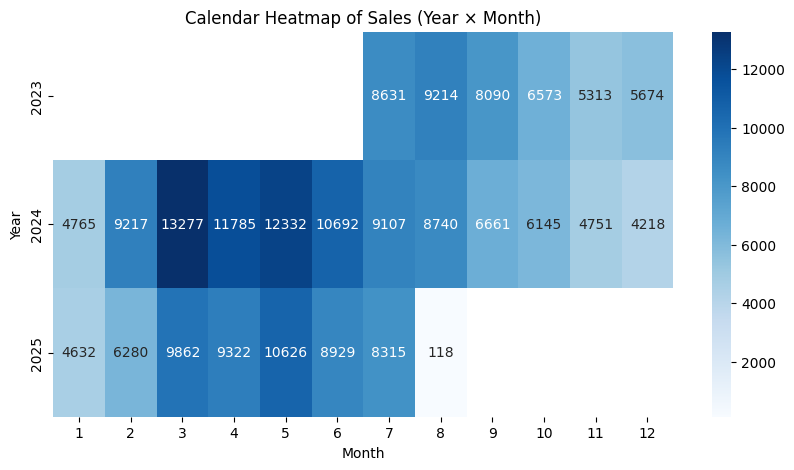

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

pivot = df.pivot_table(values='Sales', index='Year', columns='Month', aggfunc='sum')

plt.figure(figsize=(10,5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Calendar Heatmap of Sales (Year × Month)")
plt.xlabel("Month")
plt.ylabel("Year")

plt.savefig(f"../docs/p1/calendar_heatmap_year_month.png", dpi=300, bbox_inches='tight')
plt.show()


In [31]:
series = pd.read_csv("../data/processed/series_pattern_summary.csv")

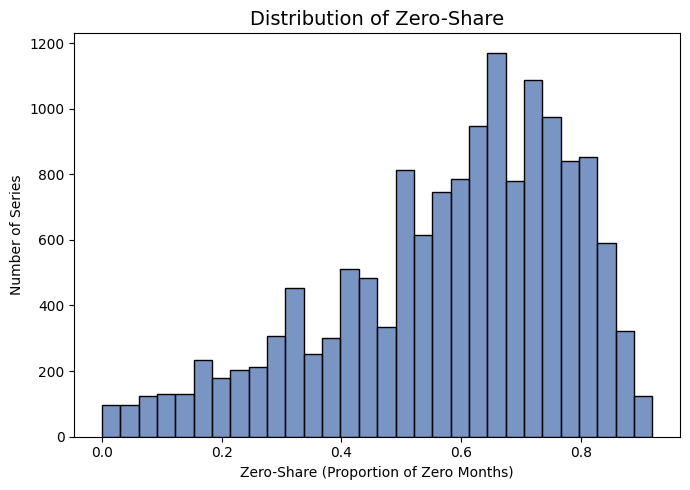

In [36]:
plt.figure(figsize=(7,5))
sns.histplot(series['zero_share'], bins=30, color='#4C72B0')

plt.title("Distribution of Zero-Share", fontsize=14)
plt.xlabel("Zero-Share (Proportion of Zero Months)")
plt.ylabel("Number of Series")

plt.tight_layout()
plt.savefig(f"../docs/p1/zero_share_distribution.png", dpi=300)
plt.show()



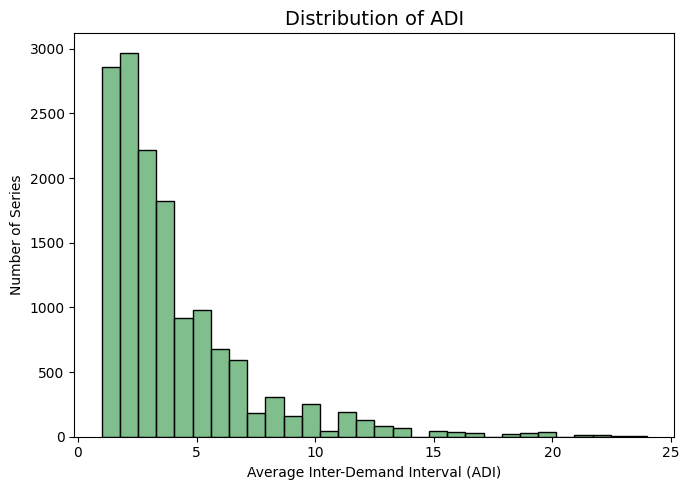

In [38]:
plt.figure(figsize=(7,5))
sns.histplot(series['ADI'].dropna(), bins=30, color='#55A868')

plt.title("Distribution of ADI", fontsize=14)
plt.xlabel("Average Inter-Demand Interval (ADI)")
plt.ylabel("Number of Series")

plt.tight_layout()
plt.savefig(f"../docs/p1/adi_distribution.png", dpi=300)
plt.show()


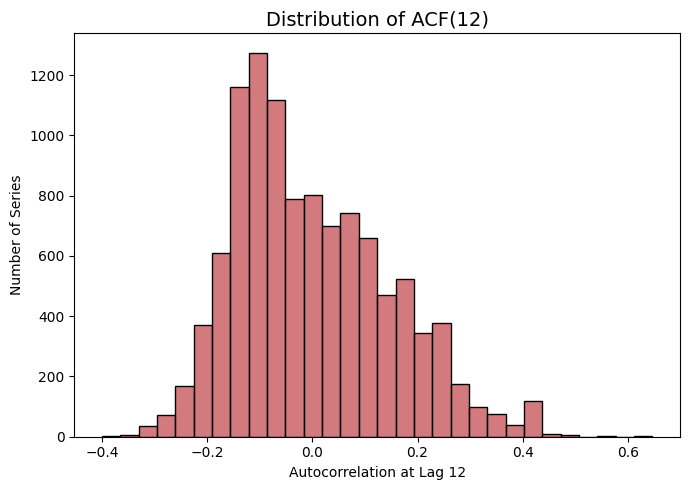

In [39]:
plt.figure(figsize=(7,5))
sns.histplot(series['ACF12'].dropna(), bins=30, color='#C44E52')

plt.title("Distribution of ACF(12)", fontsize=14)
plt.xlabel("Autocorrelation at Lag 12")
plt.ylabel("Number of Series")

plt.tight_layout()
plt.savefig(f"../docs/p1/acf12_distribution.png", dpi=300)
plt.show()


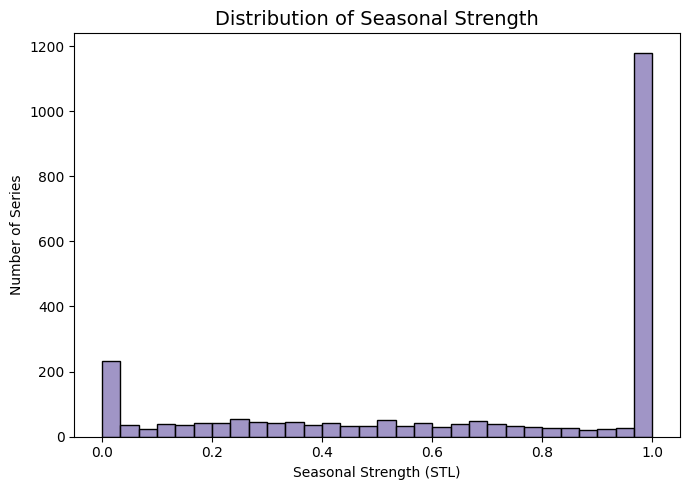

In [40]:
plt.figure(figsize=(7,5))
sns.histplot(series['seasonal_strength'].dropna(), bins=30, color='#8172B3')

plt.title("Distribution of Seasonal Strength", fontsize=14)
plt.xlabel("Seasonal Strength (STL)")
plt.ylabel("Number of Series")

plt.tight_layout()
plt.savefig(f"../docs/p1/seasonal_strength_distribution.png", dpi=300)
plt.show()


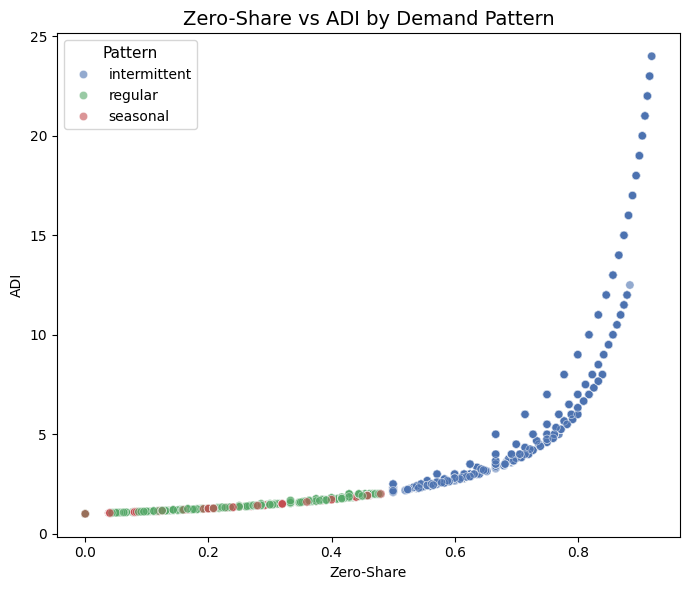

In [42]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=series,
    x='zero_share',
    y='ADI',
    hue='pattern_label',
    alpha=0.6,
    palette=['#4C72B0','#55A868','#C44E52']
)

plt.title("Zero-Share vs ADI by Demand Pattern", fontsize=14)
plt.xlabel("Zero-Share")
plt.ylabel("ADI")
plt.legend(title="Pattern", fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.savefig(f"../docs/p1/zero_vs_adi.png", dpi=300)
plt.show()


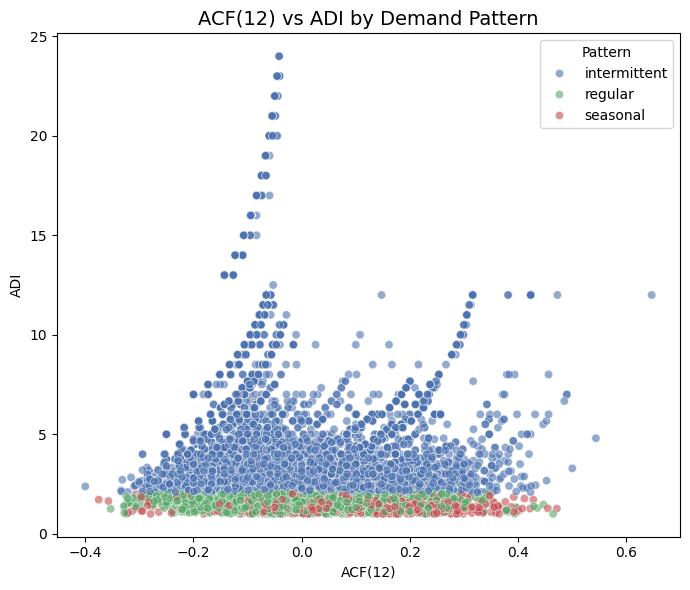

In [43]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=series,
    x='ACF12',
    y='ADI',
    hue='pattern_label',
    alpha=0.6,
    palette=['#4C72B0','#55A868','#C44E52']
)

plt.title("ACF(12) vs ADI by Demand Pattern", fontsize=14)
plt.xlabel("ACF(12)")
plt.ylabel("ADI")
plt.legend(title="Pattern")

plt.tight_layout()
plt.savefig(f"../docs/p1/acf12_vs_adi.png", dpi=300)
plt.show()


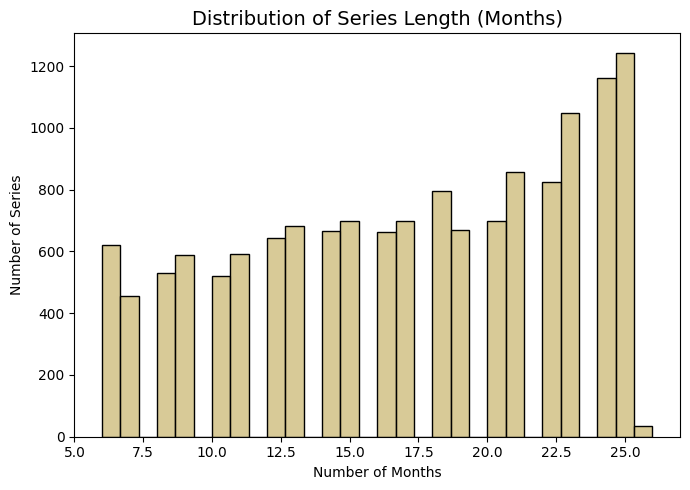

In [44]:
plt.figure(figsize=(7,5))
sns.histplot(series['n_months'], bins=30, color='#CCB974')

plt.title("Distribution of Series Length (Months)", fontsize=14)
plt.xlabel("Number of Months")
plt.ylabel("Number of Series")

plt.tight_layout()
#plt.savefig(f"../docs/p1/series_length_distribution.png", dpi=300)
plt.show()


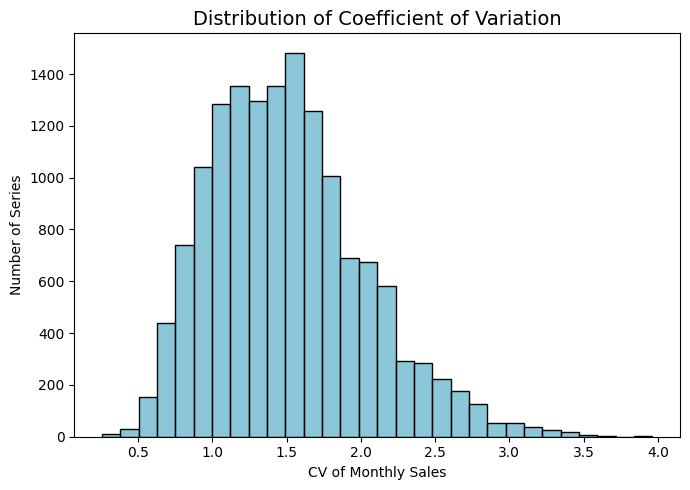

In [45]:
plt.figure(figsize=(7,5))
sns.histplot(series['cv_units'].dropna(), bins=30, color='#64B5CD')

plt.title("Distribution of Coefficient of Variation", fontsize=14)
plt.xlabel("CV of Monthly Sales")
plt.ylabel("Number of Series")

plt.tight_layout()
plt.savefig(f"../docs/p1/cv_distribution.png", dpi=300)
plt.show()
